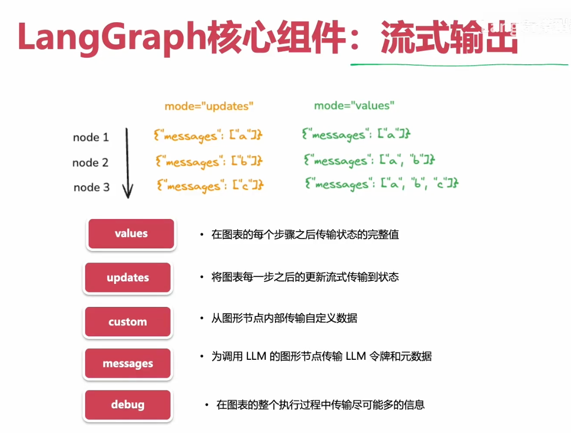


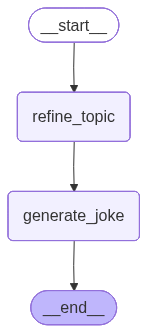

In [27]:
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(BaseModel):
    topic:str = Field(default="",description="话题")
    joke:str = Field(default="",description="笑话")


def refine_topic(state:State)->dict:
    return {
        "topic":state.topic + "和小狗",
    }


def generate_joke(state:State)->dict:
    return {
        "joke": f"这是一个关于{state.topic}的笑话",
    }

graph = (
    StateGraph(State).add_node(refine_topic)
    .add_node(generate_joke)
    .add_edge(START,"refine_topic")
    .add_edge("refine_topic","generate_joke")
    .compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))


## 一、values

In [28]:
for chunk in graph.stream({"topic":"ice cream"},stream_mode="values"):
    print(chunk)

{'topic': 'ice cream'}
{'topic': 'ice cream和小狗'}
{'topic': 'ice cream和小狗', 'joke': '这是一个关于ice cream和小狗的笑话'}


## 二、updates

In [29]:
for chunk in graph.stream({"topic":"ice cream"},stream_mode="updates"):
    print(chunk)

{'refine_topic': {'topic': 'ice cream和小狗'}}
{'generate_joke': {'joke': '这是一个关于ice cream和小狗的笑话'}}


## 三、debug


In [30]:
for chunk in graph.stream({"topic":"pirate"},stream_mode="debug"):
    print(chunk)

{'step': 1, 'timestamp': '2026-04-29T09:47:31.729309+00:00', 'type': 'task', 'payload': {'id': 'e95f17a7-f7f1-39a3-8251-b0daa3aa16e6', 'name': 'refine_topic', 'input': State(topic='pirate', joke=''), 'triggers': ('branch:to:refine_topic',)}}
{'step': 1, 'timestamp': '2026-04-29T09:47:31.729406+00:00', 'type': 'task_result', 'payload': {'id': 'e95f17a7-f7f1-39a3-8251-b0daa3aa16e6', 'name': 'refine_topic', 'error': None, 'result': {'topic': 'pirate和小狗'}, 'interrupts': []}}
{'step': 2, 'timestamp': '2026-04-29T09:47:31.729523+00:00', 'type': 'task', 'payload': {'id': 'dea0aba1-9ff8-4455-ab9d-eb175a416b4f', 'name': 'generate_joke', 'input': State(topic='pirate和小狗', joke=''), 'triggers': ('branch:to:generate_joke',)}}
{'step': 2, 'timestamp': '2026-04-29T09:47:31.729621+00:00', 'type': 'task_result', 'payload': {'id': 'dea0aba1-9ff8-4455-ab9d-eb175a416b4f', 'name': 'generate_joke', 'error': None, 'result': {'joke': '这是一个关于pirate和小狗的笑话'}, 'interrupts': []}}


## 四、messages

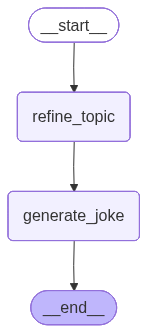

In [31]:
from model_factory import MiniMax_Model
from langchain.messages import HumanMessage

model = MiniMax_Model
def generate_joke(state:State)->dict:
    response = model.invoke(input=[
        HumanMessage(content=f"生成一个关于{state.topic}的笑话")
    ])
    return {
        "joke":response.content
    }

graph = (
    StateGraph(State).add_node(refine_topic)
    .add_node(generate_joke)
    .add_edge(START,"refine_topic")
    .add_edge("refine_topic","generate_joke")
    .compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
input = {
    "messages":[
        {"role":"user","content":"man"}
    ]
}
for chunk,metadata in graph.stream(input=input,stream_mode="messages"):
    if chunk.content:
        print(chunk.content,flush=True,end="")



以下是一个逗趣的小狗笑话：

> 主人跟小狗玩“握手”游戏。  
> 主人把手伸过去，准备等小狗轻轻碰一下。  
> 没想到小狗直接把爪子塞进主人手掌，然后抬头可怜巴巴地说：  
> **“这回握手成功了吧？先把骨头交出来！”**  

希望这个笑话能让你会心一笑！